Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Project data cleaning Complete! 'Cleaned_iris.csv' has been generated in your workspace.

Explained Variance Ratio by Component: [0.92461621 0.05301557]
Total Explained Variance (2 Components): 97.76%



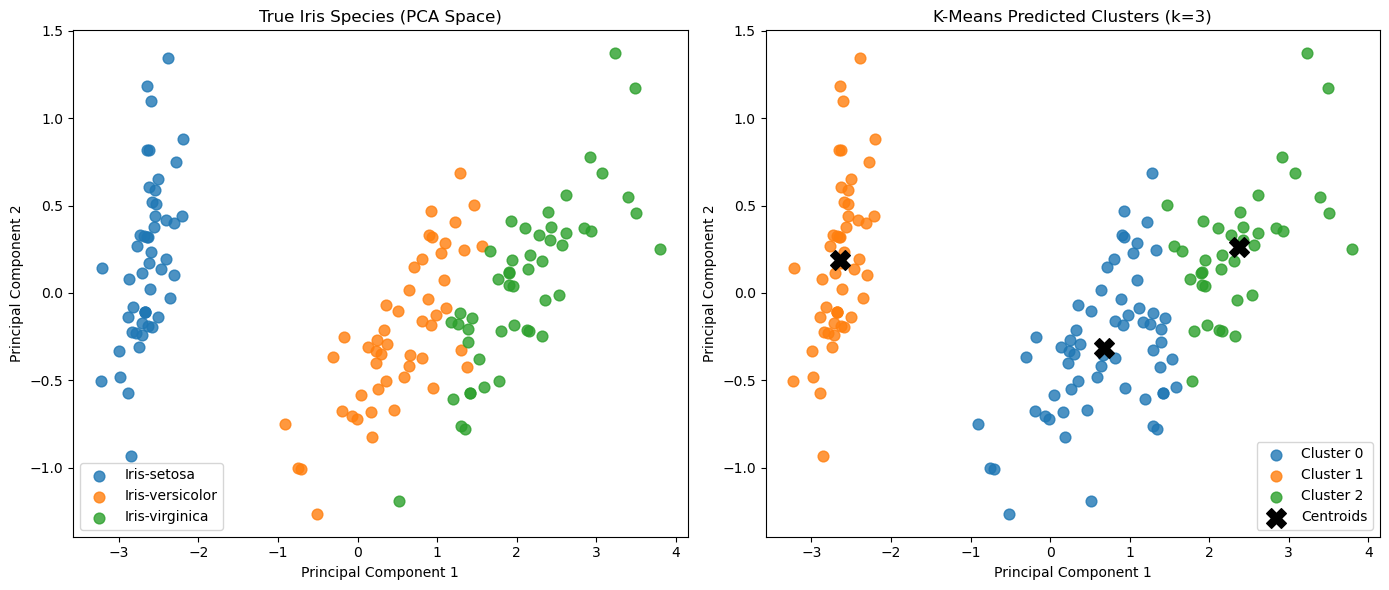

--- CONFUSION MATRIX ---
[[50  0  0]
 [ 0 48  2]
 [ 0 14 36]]

--- CLASSIFICATION REPORT ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        50
Iris-versicolor       0.77      0.96      0.86        50
 Iris-virginica       0.95      0.72      0.82        50

       accuracy                           0.89       150
      macro avg       0.91      0.89      0.89       150
   weighted avg       0.91      0.89      0.89       150



In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df=pd.read_csv("Iris.csv")
print(df.isnull().sum())

df.drop(columns=['Id'],axis=1, inplace=True )

feature_cols = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm",
]
X = df[feature_cols]

le = LabelEncoder()
df["true_label"] = le.fit_transform(df["Species"])
y = df["true_label"]


df.drop(columns=['Species'],axis=1, inplace=True )

df.to_csv('Cleaned_iris.csv', index=False)
print()
print("Project data cleaning Complete! 'Cleaned_iris.csv' has been generated in your workspace.")
print()
df.head(10)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]


# Print the explained variance ratio
variance_ratio = pca.explained_variance_ratio_
print(f"Explained Variance Ratio by Component: {variance_ratio}")
print(f"Total Explained Variance (2 Components): {sum(variance_ratio) * 100:.2f}%")
print()


plt.figure(figsize=(14, 6))

# Plot 1: True Labels
plt.subplot(1, 2, 1)
for label_idx, species_name in enumerate(le.classes_):
    subset = df[df["true_label"] == label_idx]
    plt.scatter(
        subset["pca1"], subset["pca2"], label=species_name, alpha=0.8, s=60
    )
plt.title("True Iris Species (PCA Space)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()


plt.subplot(1, 2, 2)
for cluster_id in range(3):
    subset = df[df["kmeans_cluster"] == cluster_id]
    plt.scatter(
        subset["pca1"],
        subset["pca2"],
        label=f"Cluster {cluster_id}",
        alpha=0.8,
        s=60,
    )
# Plot cluster centroids transformed to the same PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c="black",
    marker="X",
    s=200,
    label="Centroids",
)

plt.title("K-Means Predicted Clusters (k=3)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.tight_layout()
plt.show()


mapped_predictions = np.zeros_like(df["kmeans_cluster"])
for i in range(3):
    mask = df["kmeans_cluster"] == i
    if any(mask):  # Check if cluster is not empty
        majority_label = df[mask]["true_label"].value_counts().idxmax()
        mapped_predictions[mask] = majority_label

df["mapped_cluster"] = mapped_predictions

print("--- CONFUSION MATRIX ---")
print(confusion_matrix(df["true_label"], df["mapped_cluster"]))

print("\n--- CLASSIFICATION REPORT ---")
print(
    classification_report(
        df["true_label"], df["mapped_cluster"], target_names=le.classes_
    )
)